# AdvancedChemistry: chemistry theory for molecular deep learning

Role of this notebook: I am your tutor in organic, bio-, physical, and quantum chemistry. You have a university-minor chemistry background plus biochemistry/bioinformatics experience. The goal is to sharpen the chemistry needed to understand the paper notebooks, not to rebuild a full chemistry degree.

Relevant project notebooks:

- MPNNs: quantum-chemical molecular properties, atomization energies, dipoles, HOMO/LUMO, gaps.
- DeepAffinity: compound--protein binding affinity, protein sequences, ligand descriptors.
- GraphVAE/MolGAN/JT-VAE: chemically valid molecular graph generation.
- DeepDDS: drug synergy and cell-line response.
- HiGNN: molecular property prediction with atom/fragment hierarchy and attention.

Free resources:

- [OpenStax Organic Chemistry](https://openstax.org/details/books/organic-chemistry): strong open textbook; use chapters on bonding, stereochemistry, aromaticity, carbonyls, amines, biomolecules.
- [MIT OpenCourseWare Chemistry](https://ocw.mit.edu/search/?d=Chemistry): organic, biological, and quantum chemistry lecture material.
- [LibreTexts Chemistry](https://chem.libretexts.org/): useful for focused refreshers.
- [Organic Chemistry with a Biological Emphasis](https://digitalcommons.morris.umn.edu/chem_facpubs/1/) by Tim Soderberg: open organic text with biochemical framing.

Because open textbook PDFs are re-rendered over time, this notebook cites chapters/sections instead of brittle page numbers. If your local PDF has fixed pagination, annotate the page numbers directly in the markdown cells as you study.

In [1]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from rdkit import Chem
    from rdkit.Chem import AllChem, Descriptors, Draw, rdMolDescriptors
    HAS_RDKIT = True
except Exception as exc:
    HAS_RDKIT = False
    RDKIT_IMPORT_ERROR = repr(exc)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "Learning" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "Learning"
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("RDKit available:", HAS_RDKIT)

RDKit available: True


## Lesson 1 — What a molecule graph forgets and what it remembers

Most notebooks represent a molecule as a graph:

- nodes: atoms;
- edges: bonds;
- node features: element, degree, formal charge, aromaticity, hybridization, chirality;
- edge features: bond order/type, conjugation, ring membership, stereo.

This representation remembers connectivity well, but it can under-represent:

- conformational ensembles;
- solvent and pH/protonation state;
- tautomeric state;
- long-range electrostatics;
- protein environment;
- quantum electronic structure.

That gap explains why learned molecular representations are powerful but never magic. The model is only as chemically awake as the representation lets it be.

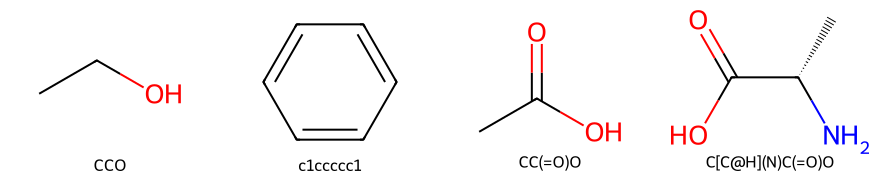

In [2]:
if HAS_RDKIT:
    smiles = ["CCO", "c1ccccc1", "CC(=O)O", "C[C@H](N)C(=O)O"]
    mols = [Chem.MolFromSmiles(s) for s in smiles]
    display(Draw.MolsToGridImage(mols, legends=smiles, molsPerRow=4, subImgSize=(220, 180)))
else:
    print(RDKIT_IMPORT_ERROR)

## Lesson 2 — Bonding, hybridization, and geometry

Useful mental model:

- `sp3`: tetrahedral, about 109.5 degrees, usually single bonds.
- `sp2`: trigonal planar, about 120 degrees, often pi systems/carbonyls/aromatics.
- `sp`: linear, about 180 degrees, alkynes/nitriles.

Why ML cares:

- Atom features often include hybridization.
- 3D quantum properties depend on geometry, not just graph topology.
- Conformer generation in RDKit is a classical approximation to a quantum/thermodynamic reality.

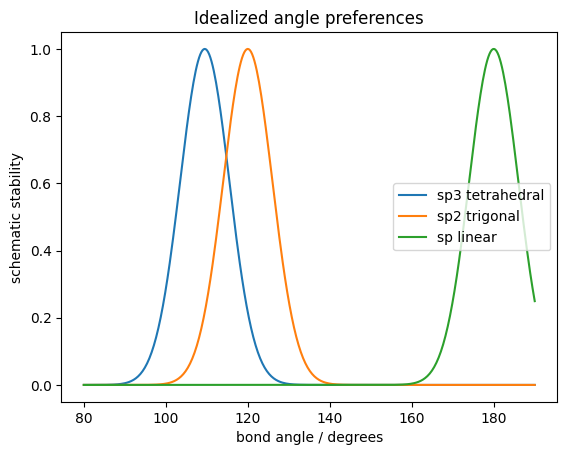

In [3]:
angles = np.linspace(80, 190, 400)
ideal = {"sp3 tetrahedral": 109.5, "sp2 trigonal": 120.0, "sp linear": 180.0}
for name, mu in ideal.items():
    y = np.exp(-0.5 * ((angles - mu) / 6) ** 2)
    plt.plot(angles, y, label=name)
plt.xlabel("bond angle / degrees")
plt.ylabel("schematic stability")
plt.title("Idealized angle preferences")
plt.legend()
plt.show()

## Lesson 3 — Aromaticity and conjugation

Aromatic systems are cyclic, planar, conjugated, and often follow Hückel's $4n+2$ pi-electron rule.

Why ML cares:

- RDKit marks aromatic atoms/bonds.
- Aromatic rings dominate drug-like scaffolds.
- Fragment models such as JT-VAE and HiGNN often preserve ring systems as meaningful substructures.

,name,smiles,aromatic_atoms,aromatic_bonds,rings
0,benzene,c1ccccc1,6,6,1
1,pyridine,n1ccccc1,6,6,1
2,cyclohexane,C1CCCCC1,0,0,1
3,imidazole,c1ncc[nH]1,5,5,1


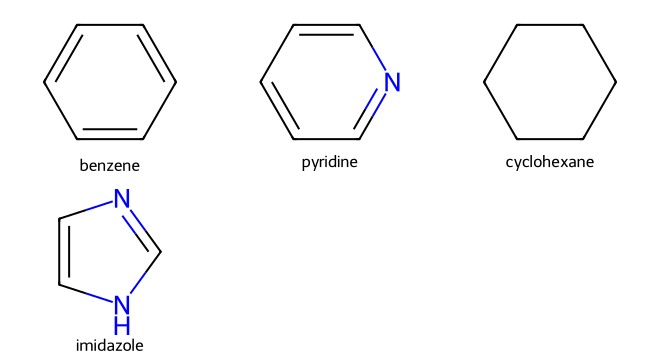

In [4]:
if HAS_RDKIT:
    examples = {
        "benzene": "c1ccccc1",
        "pyridine": "n1ccccc1",
        "cyclohexane": "C1CCCCC1",
        "imidazole": "c1ncc[nH]1",
    }
    rows = []
    for name, smi in examples.items():
        mol = Chem.MolFromSmiles(smi)
        rows.append({
            "name": name,
            "smiles": smi,
            "aromatic_atoms": sum(a.GetIsAromatic() for a in mol.GetAtoms()),
            "aromatic_bonds": sum(b.GetIsAromatic() for b in mol.GetBonds()),
            "rings": rdMolDescriptors.CalcNumRings(mol),
        })
    display(pd.DataFrame(rows))
    display(Draw.MolsToGridImage([Chem.MolFromSmiles(s) for s in examples.values()], legends=list(examples), subImgSize=(220, 180)))

## Lesson 4 — Stereochemistry and chirality

Two molecules can share the same graph and differ in 3D arrangement. Protein binding pockets are chiral; stereochemistry can decide activity, toxicity, and metabolism.

Key distinctions:

- enantiomers: non-superimposable mirror images;
- diastereomers: stereoisomers that are not mirror images;
- E/Z alkene stereochemistry;
- conformers: interconverting 3D shapes, not different connectivity.

Why ML cares:

- SMILES may or may not encode chirality (`@`, `@@`, `/`, `\\`).
- Atom/bond features in MoleculeNet often include chirality/stereo fields.
- Generative models must avoid producing impossible or unspecified stereochemistry when the task cares.

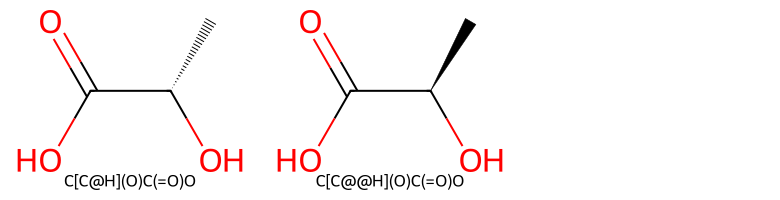

C[C@H](O)C(=O)O [(1, 'S')]
C[C@@H](O)C(=O)O [(1, 'R')]


In [5]:
if HAS_RDKIT:
    chiral = ["C[C@H](O)C(=O)O", "C[C@@H](O)C(=O)O"]
    mols = [Chem.MolFromSmiles(s) for s in chiral]
    display(Draw.MolsToGridImage(mols, legends=chiral, subImgSize=(260, 200)))
    for s, m in zip(chiral, mols):
        centers = Chem.FindMolChiralCenters(m, includeUnassigned=True)
        print(s, centers)

## Lesson 5 — Physicochemical properties used in notebooks and papers

Common learned or provided properties:

- molecular weight: size proxy;
- LogP: lipophilicity, membrane permeability vs solubility tension;
- TPSA: polar surface area, permeability/solvation proxy;
- H-bond donors/acceptors: binding and solubility;
- rotatable bonds: flexibility/entropy;
- formal charge/protonation: electrostatics and pH dependence;
- QED/drug-likeness: heuristic desirability;
- solubility/free energy/lipophilicity labels in MoleculeNet-style datasets.

Lipinski's rule of five is a filter, not a law:

$$
MW < 500,\quad \log P < 5,\quad HBD \le 5,\quad HBA \le 10.
$$

,name,MW,LogP,TPSA,HBD,HBA,rot_bonds,rings
0,aspirin,180.16,1.31,63.60,1,3,2,1
1,caffeine,194.19,-1.03,61.82,0,3,0,2
2,ibuprofen,206.28,3.07,37.30,1,1,4,1
3,imatinib fragment-ish,309.41,2.65,44.37,2,3,4,3


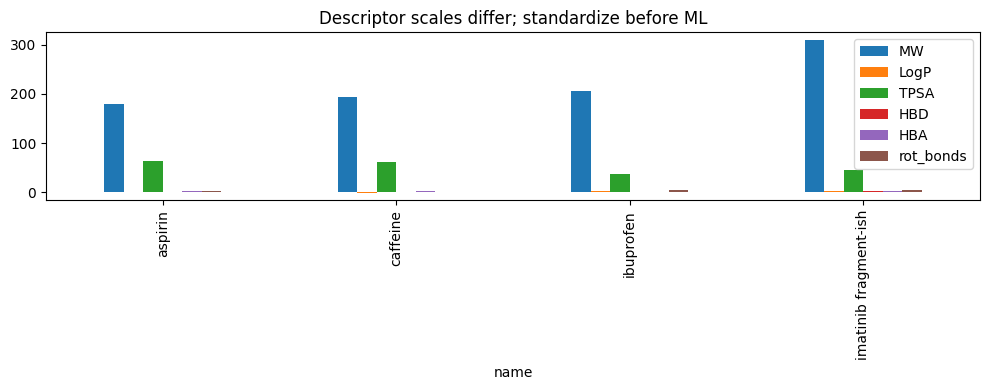

In [6]:
if HAS_RDKIT:
    drugs = {
        "aspirin": "CC(=O)OC1=CC=CC=C1C(=O)O",
        "caffeine": "Cn1cnc2n(C)c(=O)n(C)c(=O)c12",
        "ibuprofen": "CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O",
        "imatinib fragment-ish": "Cc1ccc(NC(=O)c2ccc(CN3CCNCC3)cc2)cc1",
    }
    rows = []
    for name, smi in drugs.items():
        m = Chem.MolFromSmiles(smi)
        rows.append({
            "name": name,
            "MW": Descriptors.MolWt(m),
            "LogP": Descriptors.MolLogP(m),
            "TPSA": rdMolDescriptors.CalcTPSA(m),
            "HBD": rdMolDescriptors.CalcNumHBD(m),
            "HBA": rdMolDescriptors.CalcNumHBA(m),
            "rot_bonds": rdMolDescriptors.CalcNumRotatableBonds(m),
            "rings": rdMolDescriptors.CalcNumRings(m),
        })
    df = pd.DataFrame(rows)
    display(df.round(2))
    df.set_index("name")[["MW", "LogP", "TPSA", "HBD", "HBA", "rot_bonds"]].plot(kind="bar", figsize=(10, 4))
    plt.title("Descriptor scales differ; standardize before ML")
    plt.tight_layout()
    plt.show()

## Lesson 6 — Quantum chemistry vocabulary for MPNNs

The quantum-chemistry labels in datasets like QM9 are approximations to molecular electronic structure.

Core concepts:

- electronic wavefunction $\Psi$ contains the quantum state;
- Hamiltonian $\hat{H}$ is the energy operator;
- Schrödinger equation: $\hat{H}\Psi = E\Psi$;
- Born--Oppenheimer approximation: nuclei are slow, electrons adjust quickly;
- HOMO/LUMO: highest occupied / lowest unoccupied molecular orbital;
- HOMO--LUMO gap: rough chemical reactivity/electronic excitation proxy;
- dipole moment: charge separation;
- atomization energy: energy to separate molecule into atoms.

Why MPNNs work at all: local chemical environments strongly influence many molecular properties, so message passing can approximate the map from graph/geometry to property.

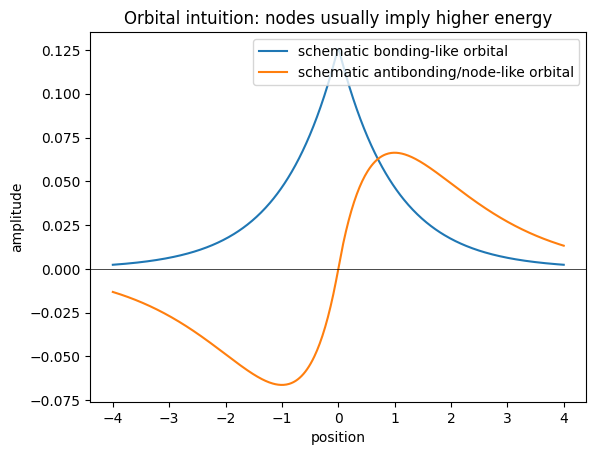

In [7]:
# Toy one-dimensional orbital shapes: not quantum chemistry software, just intuition.
x = np.linspace(-4, 4, 500)
psi_1s = np.exp(-np.abs(x))
psi_2p = x * np.exp(-np.abs(x))
plt.plot(x, psi_1s / np.linalg.norm(psi_1s), label="schematic bonding-like orbital")
plt.plot(x, psi_2p / np.linalg.norm(psi_2p), label="schematic antibonding/node-like orbital")
plt.axhline(0, color="black", lw=0.5)
plt.title("Orbital intuition: nodes usually imply higher energy")
plt.xlabel("position")
plt.ylabel("amplitude")
plt.legend()
plt.show()

## Lesson 7 — Protein--ligand binding affinity

DeepAffinity-style models connect a compound representation with a protein representation.

Thermodynamic relation:

$$
\Delta G = RT \ln K_d
$$

or, using molar units at room temperature, a lower $K_d$ means tighter binding and more negative $\Delta G$.

Chemistry and biology behind affinity:

- shape complementarity;
- hydrogen bonds;
- salt bridges/electrostatics;
- hydrophobic effect;
- pi stacking/cation-pi interactions;
- desolvation penalties;
- conformational entropy;
- induced fit/allostery.

Important warning: sequence-only protein encoders miss 3D binding-site geometry unless the model/data indirectly teaches it.

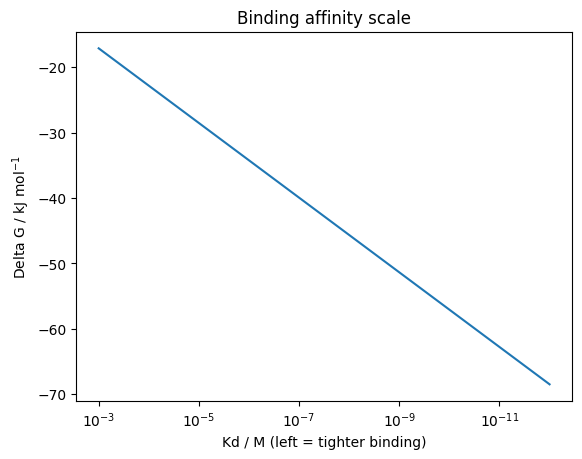

In [8]:
R = 8.314e-3  # kJ mol^-1 K^-1
T = 298.15
Kd = np.logspace(-12, -3, 200)  # M
dG = R * T * np.log(Kd)
plt.semilogx(Kd, dG)
plt.gca().invert_xaxis()
plt.xlabel("Kd / M (left = tighter binding)")
plt.ylabel("Delta G / kJ mol$^{-1}$")
plt.title("Binding affinity scale")
plt.show()

## Lesson 8 — Drug synergy and dose response

DeepDDS predicts whether two drugs act synergistically in a cellular context.

Basic vocabulary:

- additive: combined effect equals expectation from single drugs;
- synergistic: combined effect exceeds expectation;
- antagonistic: combined effect is weaker than expectation;
- Bliss/Loewe/HSA/ZIP: different mathematical baselines for expected combination effect.

Why chemistry alone is not enough: synergy depends on targets, pathways, cell-line omics, dosing, transporters, metabolism, and feedback loops.

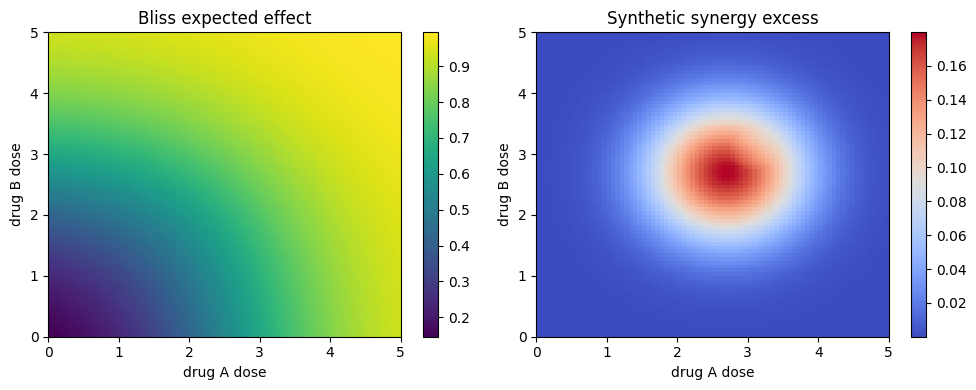

In [9]:
dose_a = np.linspace(0, 5, 80)
dose_b = np.linspace(0, 5, 80)
A, B = np.meshgrid(dose_a, dose_b)
Ea = 1 / (1 + np.exp(-(A - 2.5)))
Eb = 1 / (1 + np.exp(-(B - 2.5)))
bliss = Ea + Eb - Ea * Eb
synergy_bonus = 0.18 * np.exp(-((A - 2.7) ** 2 + (B - 2.7) ** 2) / 1.2)
observed = np.clip(bliss + synergy_bonus, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(bliss, origin="lower", extent=[0, 5, 0, 5], aspect="auto")
axes[0].set_title("Bliss expected effect")
im1 = axes[1].imshow(observed - bliss, origin="lower", extent=[0, 5, 0, 5], aspect="auto", cmap="coolwarm")
axes[1].set_title("Synthetic synergy excess")
for ax in axes:
    ax.set_xlabel("drug A dose")
    ax.set_ylabel("drug B dose")
plt.colorbar(im0, ax=axes[0])
plt.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()

## Lesson 9 — Fragment chemistry and molecular generation

Generative models need constraints. Organic molecules are not arbitrary graphs:

- typical valences must be satisfied;
- rings have strain/aromaticity rules;
- functional groups bring predictable reactivity;
- charged states and salts require careful normalization;
- synthetic accessibility is not guaranteed by validity.

JT-VAE uses chemically meaningful substructures/cliques. HiGNN uses fragments to add hierarchy. BRICS-like fragmentation reflects medicinal-chemistry intuition: molecules are built from linkable pieces.

BRICS fragments:
  [1*]C(C)=O
  [16*]c1ccc([16*])cc1
  [3*]O[3*]
  [4*]CC[4*]
  [5*]N1CCOCC1
  [5*]N[5*]


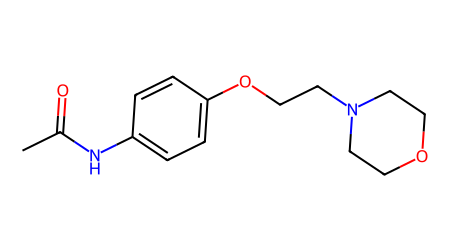

In [10]:
if HAS_RDKIT:
    from rdkit.Chem import BRICS
    smi = "CC(=O)Nc1ccc(OCCN2CCOCC2)cc1"
    mol = Chem.MolFromSmiles(smi)
    frags = sorted(BRICS.BRICSDecompose(mol))
    print("BRICS fragments:")
    for frag in frags:
        print(" ", frag)
    display(Draw.MolToImage(mol, size=(450, 250)))

## Lesson 10 — Chemistry reading checklist for every molecular ML paper

Ask:

1. What chemical state is represented: neutralized, protonated, tautomer-specific, stereospecific?
2. Are labels quantum-calculated, experimental, assay-derived, or database-curated?
3. Does the representation include 3D geometry?
4. Does the split test scaffold generalization?
5. Are invalid generated molecules filtered after the fact?
6. Are reported attention weights chemically plausible or merely diagnostic?
7. Does the model learn chemistry, dataset bias, or both?

This is where your bioinformatics instincts help: data provenance is biology's quiet dragon, and chemistry has the same dragon wearing a lab coat.

## Lesson 11 — Acid/base chemistry, protonation, and pH

Many molecular ML failures come from pretending a molecule has one timeless structure. In solution, protonation depends on pH and pKa.

Henderson--Hasselbalch:

For an acid $HA \rightleftharpoons H^+ + A^-$,

$$
\mathrm{pH}=\mathrm{p}K_a+\log_{10}\frac{[A^-]}{[HA]}.
$$

Fraction deprotonated:

$$
\alpha_{A^-}=\frac{1}{1+10^{pK_a-pH}}.
$$

Why ML cares:

- formal charge changes graph features;
- binding pockets select protonation states;
- LogP/logD differ because logD is pH-dependent;
- generated molecules may be valid as graphs but implausible at physiological pH.

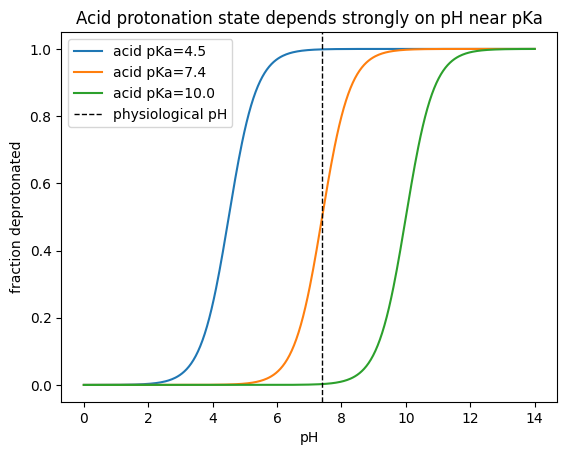

In [11]:
pH = np.linspace(0, 14, 400)
pKas = [4.5, 7.4, 10.0]
for pKa in pKas:
    frac_deprot = 1 / (1 + 10 ** (pKa - pH))
    plt.plot(pH, frac_deprot, label=f"acid pKa={pKa}")
plt.axvline(7.4, color="black", ls="--", lw=1, label="physiological pH")
plt.xlabel("pH")
plt.ylabel("fraction deprotonated")
plt.title("Acid protonation state depends strongly on pH near pKa")
plt.legend()
plt.show()

## Lesson 12 — Tautomers and resonance: same formula, different graph emphasis

Resonance structures are not distinct molecules; they are bookkeeping for delocalized electrons. Tautomers, however, are interconverting constitutional isomers with different atom connectivity/proton placement.

ML consequences:

- canonical SMILES does not automatically solve tautomer equivalence;
- different databases may store different tautomers;
- generated molecules may exploit tautomer edge cases;
- binding affinity may favor one tautomer in a pocket.

RDKit and other toolkits have tautomer enumerators, but tautomer standardization is a modeling decision, not a universal truth.

Enumerated tautomers: 2


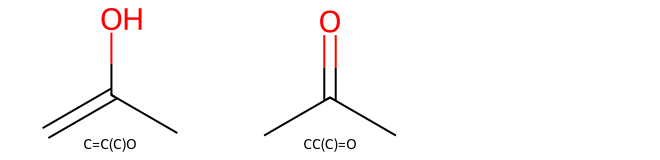

In [12]:
if HAS_RDKIT:
    from rdkit.Chem.MolStandardize import rdMolStandardize
    taut = rdMolStandardize.TautomerEnumerator()
    mol = Chem.MolFromSmiles("CC(=O)NC")  # simple amide; limited tautomerism
    keto_enol = Chem.MolFromSmiles("CC(=O)C")
    tautomers = list(taut.Enumerate(keto_enol))
    print("Enumerated tautomers:", len(tautomers))
    display(Draw.MolsToGridImage(tautomers[:8], legends=[Chem.MolToSmiles(m) for m in tautomers[:8]], subImgSize=(220, 160)))

## Lesson 13 — Solvation, hydrophobic effect, and permeability

Binding is not just ligand + protein. It is ligand + protein + water + ions + entropy.

Key ideas:

- Polar groups interact favorably with water but may pay desolvation penalties entering hydrophobic pockets.
- Hydrophobic groups can gain binding affinity by displacing ordered water.
- Membrane permeability often prefers lower polarity, but solubility prefers higher polarity.
- TPSA and LogP are crude but useful proxies.

This is why drug design is full of tradeoffs. A model optimizing one property can easily damage another.

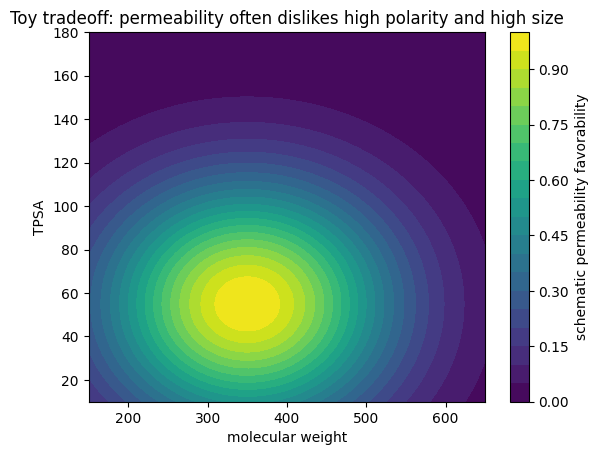

In [13]:
mw = np.linspace(150, 650, 120)
tpsa = np.linspace(10, 180, 120)
MW, TPSA = np.meshgrid(mw, tpsa)
# Toy permeability score, not a real model.
score = np.exp(-((TPSA - 55) / 55) ** 2) * np.exp(-((MW - 350) / 180) ** 2)
plt.contourf(MW, TPSA, score, levels=20, cmap="viridis")
plt.colorbar(label="schematic permeability favorability")
plt.xlabel("molecular weight")
plt.ylabel("TPSA")
plt.title("Toy tradeoff: permeability often dislikes high polarity and high size")
plt.show()

## Lesson 14 — Reaction/functional group intuition for generated molecules

Generative models can produce molecules that are formally valid but chemically undesirable.

Watch for:

- reactive acyl halides, aldehydes, Michael acceptors;
- strained rings;
- unstable peroxides;
- pan-assay interference compounds (PAINS);
- redox-active motifs;
- promiscuous aggregators;
- toxicophores.

The papers here mostly focus on representation/generation, not full medicinal chemistry triage. When you use generated molecules seriously, add filters and expert review.

In [14]:
if HAS_RDKIT:
    smarts = {
        "aldehyde": "[CX3H1](=O)[#6]",
        "acyl_chloride": "C(=O)Cl",
        "michael_acceptor": "C=CC=O",
        "nitro": "[NX3](=O)=O",
    }
    examples = {
        "benzaldehyde": "O=Cc1ccccc1",
        "acetyl chloride": "CC(=O)Cl",
        "methyl vinyl ketone": "C=CC(=O)C",
        "nitrobenzene": "O=[N+]([O-])c1ccccc1",
    }
    rows = []
    for name, smi in examples.items():
        mol = Chem.MolFromSmiles(smi)
        row = {"name": name, "smiles": smi}
        for label, patt in smarts.items():
            row[label] = mol.HasSubstructMatch(Chem.MolFromSmarts(patt))
        rows.append(row)
    display(pd.DataFrame(rows))

,name,smiles,aldehyde,acyl_chloride,michael_acceptor,nitro
0,benzaldehyde,O=Cc1ccccc1,True,False,False,False
1,acetyl chloride,CC(=O)Cl,False,True,False,False
2,methyl vinyl ketone,C=CC(=O)C,False,False,True,False
3,nitrobenzene,O=[N+]([O-])c1ccccc1,False,False,False,False


## Lesson 15 — From molecular orbitals to descriptors

Quantum descriptors in QM9-like work include:

- $\mu$: dipole moment;
- $\alpha$: isotropic polarizability;
- $\epsilon_{HOMO}$ and $\epsilon_{LUMO}$;
- gap $\Delta\epsilon = \epsilon_{LUMO}-\epsilon_{HOMO}$;
- electronic spatial extent;
- zero-point vibrational energy;
- internal energies/free energies/enthalpies;
- heat capacity.

Message-passing models approximate these from atoms, bonds, and sometimes 3D distances. Without 3D geometry, stereochemical and conformational effects become hard or impossible to distinguish.

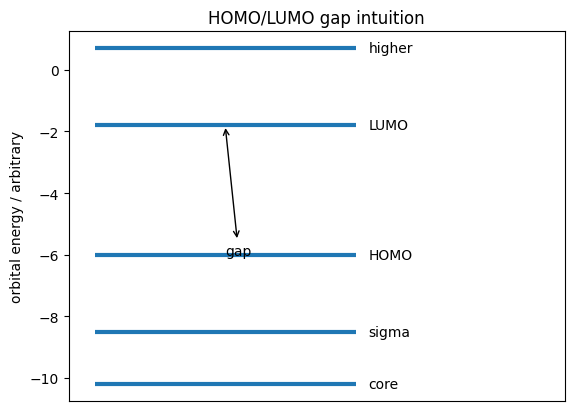

In [15]:
# Schematic energy-level diagram.
levels = [-10.2, -8.5, -6.0, -1.8, 0.7]
labels = ["core", "sigma", "HOMO", "LUMO", "higher"]
for e, lab in zip(levels, labels):
    plt.hlines(e, 0, 1, lw=3)
    plt.text(1.05, e, lab, va="center")
plt.annotate("gap", xy=(0.5, -1.8), xytext=(0.5, -6.0), arrowprops={"arrowstyle": "<->"})
plt.xlim(-0.1, 1.8)
plt.ylabel("orbital energy / arbitrary")
plt.xticks([])
plt.title("HOMO/LUMO gap intuition")
plt.show()

## Lesson 16 — Assays, noise, and biological labels

A chemical structure is clean; a biological label is often messy.

Sources of label noise:

- batch effects;
- assay format differences;
- protein construct differences;
- cell-line drift;
- compound purity/degradation;
- solubility/aggregation;
- censored values such as `>10 µM`;
- different activity units: IC50, Ki, Kd, EC50.

Affinity conversion:

$$
pK_d = -\log_{10}(K_d \text{ in molar})
$$

Small numerical differences can matter: one log unit is a tenfold affinity change.

In [16]:
Kd_uM = np.array([100, 10, 1, 0.1, 0.01])
pKd = -np.log10(Kd_uM * 1e-6)
pd.DataFrame({"Kd_uM": Kd_uM, "pKd": pKd})

,Kd_uM,pKd
0,100.00,4.0
1,10.00,5.0
2,1.00,6.0
3,0.10,7.0
4,0.01,8.0


## Lesson 17 — Chemical validity vs. synthesizability vs. usefulness

Validity: RDKit can parse and sanitize the molecule.

Synthesizability: a chemist can reasonably make it.

Usefulness: it has the desired activity, selectivity, ADMET profile, novelty, and IP position.

These are nested only loosely. A valid molecule may be impossible to synthesize; a synthesizable molecule may be toxic; a potent molecule may be insoluble. Generative models often optimize the first layer because it is easy to measure.

## Lesson 18 — Chemistry map of the repo

- **MPNNs:** bonding, atom environments, quantum descriptors, graph locality.
- **DeepAffinity:** ligand properties, protein binding thermodynamics, sequence/protein representation.
- **GraphVAE:** graph validity, atom/bond categorical distributions, padded graph tensors.
- **JT-VAE:** rings, fragments, cliques, synthetic/structural priors.
- **DeepDDS:** pharmacology, synergy, pathway context, drug-pair interactions.
- **MolGAN:** validity/uniqueness/novelty, reward design, property optimization.
- **HiGNN:** BRICS/fragments, hierarchical structure, property-relevant substructures.